In [1]:
import fig01
import matplotlib.pyplot as plt
import numpy as np

from drift_diffusion.model import DriftDiffusionModel, pdf
from drift_diffusion.sim import sim_ddm

# notebook defaults
plt.rcParams.update({"font.size": 12, "font.family": "Helvetica"})
n_samples = 2000
rng = np.random.default_rng(seed=0)

In [2]:
# fit ddm to block or rightward and leftward trials
df195 = fig01.preproc_df()

ddms = {}
blocks = {}
dir_labels = {0: "R", np.pi: "L"}

min_len = min([len(df195.query("dotDirection == @d")) for d in dir_labels])
idx = rng.integers(0, min_len - n_samples + 1)

for dot_direction, label in dir_labels.items():
    df_dir = df195.query("dotDirection == @dot_direction")

    block = df_dir.iloc[idx : idx + n_samples]
    blocks[label] = block

    ddm = DriftDiffusionModel(a="+1", t0="+1", v="-1 + coherence", z="+1")
    ddm.fit(block, block["y"])
    ddms[label] = ddm

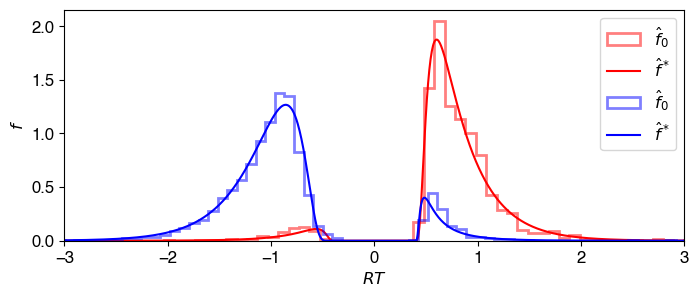

In [183]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = {"R": "r", "L": "b"}
y = np.linspace(-3, +3, 1000)

for label, color in colors.items():
    a, t0, beta_v, z = ddms[label].params_
    v = beta_v * (0.85 if label == "R" else -0.85)

    ax.hist(
        blocks[label]["y"], bins=150, histtype="step", density=True, color=color, alpha=0.5, lw=2, label=r"$\hat{f}_0$"
    )
    ax.plot(y, pdf(y, a=a, t0=t0, v=v, z=z), color=color, label=r"$\hat{f}^*$")

ax.legend()

ax.set(xlim=[-3, +3], ylabel=r"$f$", xlabel=r"$RT$")

fig.savefig("tmp.pdf", transparent=True, bbox_inches="tight")

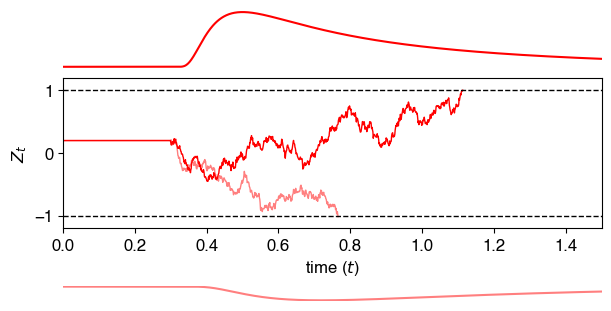

In [184]:
a, t0, v, z = 1, 0.3, 1, 0.2
fig, axs = plt.subplots(3, 1, figsize=(6, 3), sharex=True, height_ratios=[0.4, 1, 0.1], layout="constrained")

for s in [5, 7]:
    z_t = sim_ddm(dt=0.001, t=t0, z=z, v=v, a=a * 2, seed=s)
    axs[1].plot(np.arange(len(z_t)) * 0.001, z_t, "r", alpha=1 if s == 5 else 0.5, lw=1)

axs[1].set(ylim=(-a - 0.2, a + 0.2), xlim=(0, 1.5), ylabel=r"$Z_t$", xlabel=r"time ($t$)")
axs[1].tick_params(labelbottom=True)
[axs[1].axhline(val, ls="--", c="k", lw=1) for val in (a, -a)]

y = np.linspace(0, 1.5, 1000)
axs[0].plot(y, pdf(y, a, t0, v, z), "r")
axs[2].plot(y, pdf(-y, a, t0, v, z), "r", alpha=0.5)
axs[2].invert_yaxis()
[ax.axis("off") for ax in (axs[0], axs[2])]

fig.savefig("tmp.pdf", transparent=True, bbox_inches="tight")